# Home Credit Default Risk
## Notebook 02 - Data Quality Assessment

### Objectives
- Identify missing values across all columns
- Detect duplicate records
- Validate data types
- Find impossible or suspicious values
- Document all data quality issues for cleaning phase

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
train = pd.read_csv("../data/application_train.csv")
print(f"Dataset loaded: {train.shape[0]:,} rows, {train.shape[1]} columns")

Dataset loaded: 307,511 rows, 122 columns


In [3]:
# Calculate missing values
missing = pd.DataFrame({
    'Missing Count': train.isnull().sum(),
    'Missing %': (train.isnull().sum() / len(train) * 100).round(2)
})

# Filter only columns with missing values
missing = missing[missing['Missing Count'] > 0]
missing = missing.sort_values('Missing %', ascending=False)

print(f"Columns with missing values: {len(missing)} out of {train.shape[1]}")
print()
print(missing)

Columns with missing values: 67 out of 122

                              Missing Count  Missing %
COMMONAREA_MEDI                      214865      69.87
COMMONAREA_MODE                      214865      69.87
COMMONAREA_AVG                       214865      69.87
NONLIVINGAPARTMENTS_MODE             213514      69.43
NONLIVINGAPARTMENTS_MEDI             213514      69.43
NONLIVINGAPARTMENTS_AVG              213514      69.43
FONDKAPREMONT_MODE                   210295      68.39
LIVINGAPARTMENTS_AVG                 210199      68.35
LIVINGAPARTMENTS_MEDI                210199      68.35
LIVINGAPARTMENTS_MODE                210199      68.35
FLOORSMIN_MEDI                       208642      67.85
FLOORSMIN_MODE                       208642      67.85
FLOORSMIN_AVG                        208642      67.85
YEARS_BUILD_MODE                     204488      66.50
YEARS_BUILD_MEDI                     204488      66.50
YEARS_BUILD_AVG                      204488      66.50
OWN_CAR_AGE          

In [4]:
print(train.groupby('FLAG_OWN_CAR')['OWN_CAR_AGE'].agg(['count', 'mean', lambda x: x.isnull().sum()]))

               count       mean  <lambda_0>
FLAG_OWN_CAR                               
N                  0        NaN      202924
Y             104582  12.061091           5


## Observation: Missing Values Overview

- 67 out of 122 columns have missing values
- Three categories identified:
  - High missing (>40%): Building-related columns (COMMONAREA, FLOORSMIN etc.)
  - Medium missing (10-40%): To be investigated
  - Low missing (<5%): AMT_GOODS_PRICE, AMT_ANNUITY etc.

### Key Finding: OWN_CAR_AGE
- 65.99% missing (202,924 rows)
- Missingness is structural — all 202,924 people without cars have no car age
- Type: Missing At Random (MAR) — depends on FLAG_OWN_CAR
- Treatment: Fill with 0 where FLAG_OWN_CAR = N

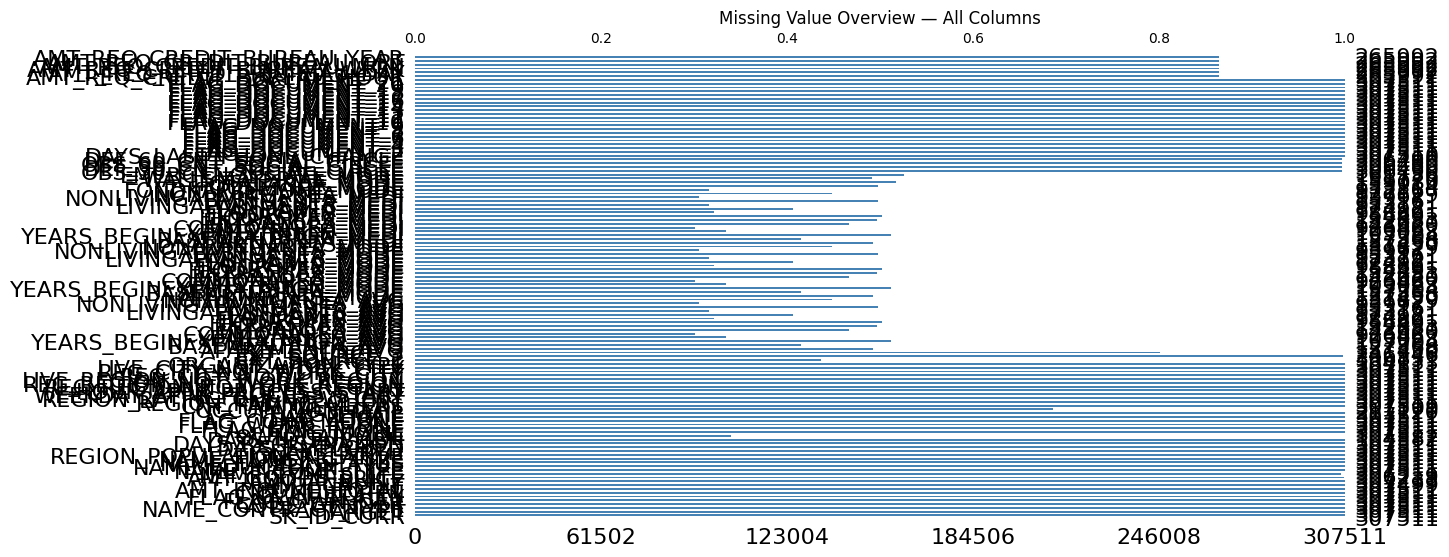

In [5]:
plt.figure(figsize=(12, 6))
msno.bar(train, figsize=(12, 6), color='steelblue')
plt.title('Missing Value Overview — All Columns')
plt.show()

<Figure size 1600x800 with 0 Axes>

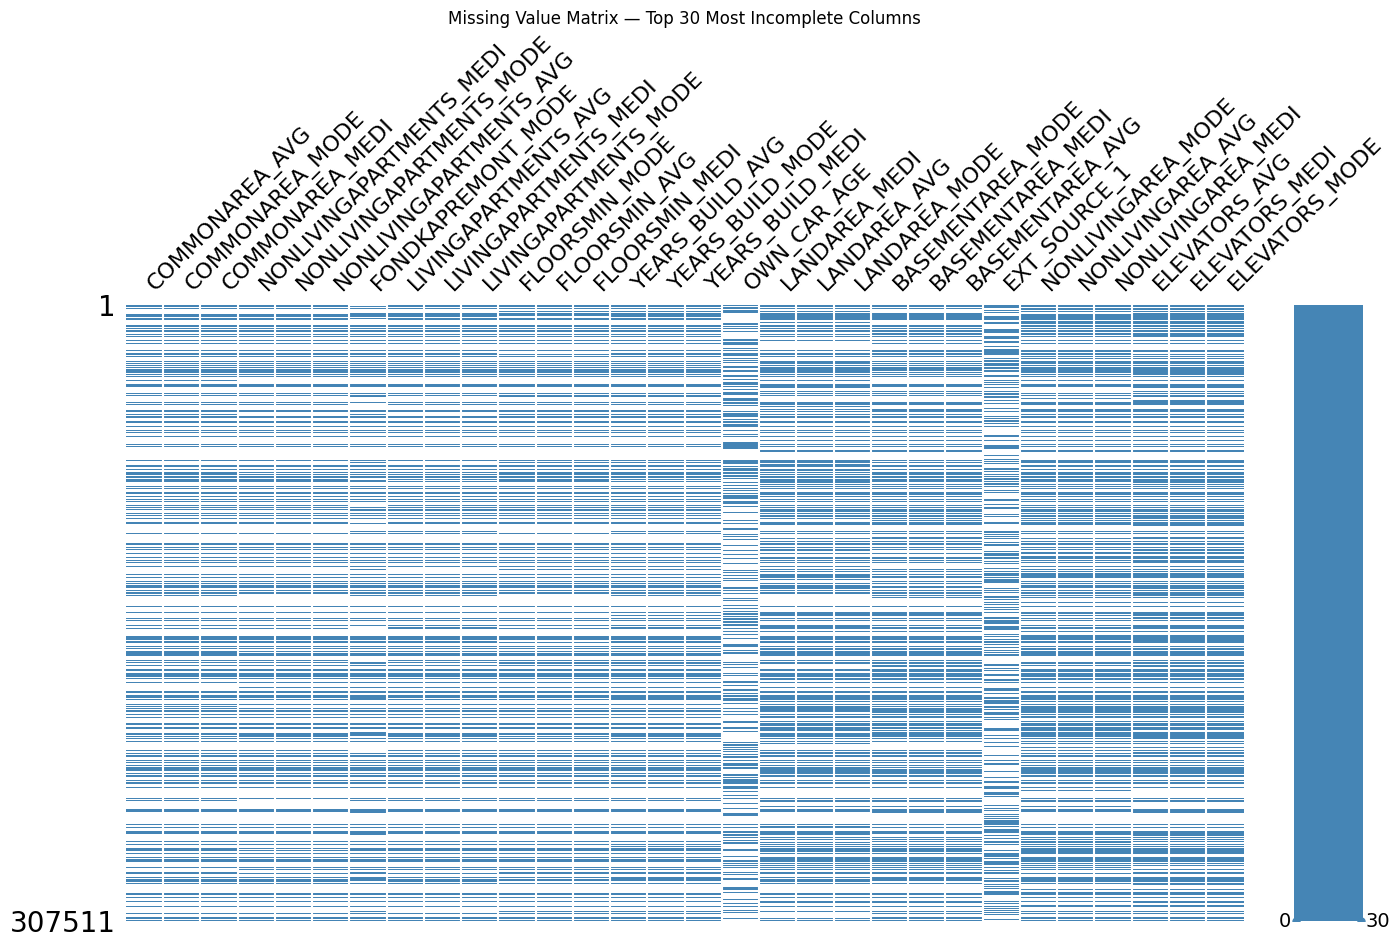

In [6]:
# Show top 30 most missing columns
top_missing_cols = train.isnull().sum().sort_values(ascending=False).head(30).index.tolist()

plt.figure(figsize=(16, 8))
msno.matrix(
    train[top_missing_cols],
    figsize=(16, 8),
    color=(0.27, 0.52, 0.71)
)
plt.title('Missing Value Matrix — Top 30 Most Incomplete Columns')
plt.show()

## Observation: Missing Value Matrix

- Top 30 most incomplete columns visualized
- Building-related columns (COMMONAREA, NONLIVINGAPARTMENTS, FLOORSMIN) 
  show identical missing patterns — missing as a group from same source
- OWN_CAR_AGE missingness is structural (linked to FLAG_OWN_CAR = N)
- Three types of missingness identified:
  - MAR: OWN_CAR_AGE (depends on FLAG_OWN_CAR)
  - MNAR: Building columns (missing because building has no records)
  - MCAR: AMT_ANNUITY, CNT_FAM_MEMBERS (random, very few missing)

In [7]:
duplicates = train.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")
print(f"Percentage of duplicate rows: {duplicates / len(train) * 100:.2f}%")

Number of duplicate rows: 0
Percentage of duplicate rows: 0.00%


## Observation: Duplicate Records

- Zero duplicate rows found in the dataset
- Each row represents a unique loan application
- SK_ID_CURR is a unique identifier per application
- No action required

In [8]:
# Summarize data types
dtype_summary = train.dtypes.value_counts()
print("Data Type Summary:")
print(dtype_summary)
print()

# Show columns by data type
print("Float columns  :", train.select_dtypes(include='float64').shape[1])
print("Integer columns:", train.select_dtypes(include='int64').shape[1])
print("String columns :", train.select_dtypes(include='str').shape[1])

Data Type Summary:
float64    65
int64      41
str        16
Name: count, dtype: int64

Float columns  : 65
Integer columns: 41
String columns : 16


In [9]:
# Find float columns that are actually integers
float_cols = train.select_dtypes(include='float64').columns

suspicious = []
for col in float_cols:
    # Check if all non-missing values are whole numbers
    non_missing = train[col].dropna()
    if (non_missing == non_missing.round()).all():
        suspicious.append(col)

print(f"Float columns that are actually integers: {len(suspicious)}")
print()
for col in suspicious:
    print(col)

Float columns that are actually integers: 13

OWN_CAR_AGE
CNT_FAM_MEMBERS
OBS_30_CNT_SOCIAL_CIRCLE
DEF_30_CNT_SOCIAL_CIRCLE
OBS_60_CNT_SOCIAL_CIRCLE
DEF_60_CNT_SOCIAL_CIRCLE
DAYS_LAST_PHONE_CHANGE
AMT_REQ_CREDIT_BUREAU_HOUR
AMT_REQ_CREDIT_BUREAU_DAY
AMT_REQ_CREDIT_BUREAU_WEEK
AMT_REQ_CREDIT_BUREAU_MON
AMT_REQ_CREDIT_BUREAU_QRT
AMT_REQ_CREDIT_BUREAU_YEAR


## Observation: Data Type Validation

- float64: 65 columns
- int64  : 41 columns  
- str    : 16 columns

### Issue Found: 13 Float Columns Should Be Integers
Columns like OWN_CAR_AGE, CNT_FAM_MEMBERS, AMT_REQ_CREDIT_BUREAU_*
are stored as float64 due to pandas behavior with missing values.
Integer columns with any missing value get auto-converted to float.

Action: Convert to integer after missing value treatment in Notebook 03.

In [10]:
print(train['DAYS_EMPLOYED'].describe())
print()
print(f"Positive values: {(train['DAYS_EMPLOYED'] > 0).sum()}")
print(f"Negative values: {(train['DAYS_EMPLOYED'] < 0).sum()}")
print(f"Zero values    : {(train['DAYS_EMPLOYED'] == 0).sum()}")

count    307511.000000
mean      63815.045904
std      141275.766519
min      -17912.000000
25%       -2760.000000
50%       -1213.000000
75%        -289.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64

Positive values: 55374
Negative values: 252135
Zero values    : 2


In [11]:
anomaly = (train['DAYS_EMPLOYED'] == 365243).sum()
print(f"Rows with DAYS_EMPLOYED = 365243: {anomaly:,}")
print(f"Percentage: {anomaly/len(train)*100:.2f}%")
print()
# Check what kind of people have this value
print(train[train['DAYS_EMPLOYED'] == 365243]['NAME_INCOME_TYPE'].value_counts())

Rows with DAYS_EMPLOYED = 365243: 55,374
Percentage: 18.01%

NAME_INCOME_TYPE
Pensioner     55352
Unemployed       22
Name: count, dtype: int64


In [12]:
# Replace 365243 with NaN — it means "not employed"
train['DAYS_EMPLOYED_CLEAN'] = train['DAYS_EMPLOYED'].replace(365243, np.nan)

# Now convert to years for readability
train['YEARS_EMPLOYED'] = abs(train['DAYS_EMPLOYED_CLEAN']) / 365

print(f"Clean mean employment : {train['YEARS_EMPLOYED'].mean():.1f} years")
print(f"Clean median employment: {train['YEARS_EMPLOYED'].median():.1f} years")
print(f"Not employed (NaN)    : {train['YEARS_EMPLOYED'].isnull().sum():,}")

Clean mean employment : 6.5 years
Clean median employment: 4.5 years
Not employed (NaN)    : 55,374


C:\Users\devir\AppData\Local\Temp\ipykernel_33104\2690890537.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train['DAYS_EMPLOYED_CLEAN'] = train['DAYS_EMPLOYED'].replace(365243, np.nan)
C:\Users\devir\AppData\Local\Temp\ipykernel_33104\2690890537.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train['YEARS_EMPLOYED'] = abs(train['DAYS_EMPLOYED_CLEAN']) / 365


## Observation: DAYS_EMPLOYED — Sentinel Value Found

- DAYS_EMPLOYED = 365,243 found in 55,374 rows (18.01%)
- 365,243 = 1,000 years — impossible employment duration
- This is a sentinel value meaning "not employed"
- 55,352 Pensioners + 22 Unemployed people have this value

Impact on statistics:
- Raw mean: 63,815 days (174 years) ❌ meaningless
- Clean mean: 6.5 years ✅ realistic
- Clean median: 4.5 years ✅ realistic

Action: Replace 365,243 with NaN in data cleaning phase

## Notebook 02 Summary — Data Quality Assessment

### Findings

| Issue | Details | Action |
|---|---|---|
| Missing Values | 67/122 columns affected | Treat in Notebook 03 |
| Building columns | 48-70% missing as a group | Impute or drop |
| OWN_CAR_AGE | Structurally missing (MAR) | Fill 0 where no car |
| Duplicate Rows | 0 duplicates found | No action needed |
| Data Types | 13 float columns should be int | Convert after imputation |
| CODE_GENDER | 4 XNA values | Replace with mode |
| DAYS_EMPLOYED | 365,243 sentinel value (18%) | Replace with NaN |

### Most Critical Finding
DAYS_EMPLOYED sentinel value affects 18% of dataset and 
completely distorts mean employment statistics.

### Next Steps
Notebook 03: Missing Value Analysis — deep dive into 
imputation strategies for each column group